In [1]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_csv("data/train.csv")
df.head()

,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


In [3]:
# 타겟 확인
df['임신 성공 여부'].value_counts()
df['임신 성공 여부'].value_counts(normalize=True)

임신 성공 여부
0    0.741651
1    0.258349
Name: proportion, dtype: float64

In [4]:
# 컬럼 타입 확인
df.dtypes.value_counts()

float64    29
object     21
int64      19
Name: count, dtype: int64

In [5]:
# 결측치 TOP20
df.isnull().sum().sort_values(ascending=False).head(20)

난자 해동 경과일                254915
PGS 시술 여부                254422
PGD 시술 여부                254172
착상 전 유전 검사 사용 여부         253633
임신 시도 또는 마지막 임신 경과 연수    246981
배아 해동 경과일                215982
난자 채취 경과일                 57488
난자 혼합 경과일                 53735
배아 이식 경과일                 43566
총 생성 배아 수                  6291
저장된 신선 난자 수                6291
기증자 정자와 혼합된 난자 수           6291
파트너 정자와 혼합된 난자 수           6291
혼합된 난자 수                   6291
해동 난자 수                    6291
수집된 신선 난자 수                6291
이식된 배아 수                   6291
배아 생성 주요 이유                6291
해동된 배아 수                   6291
미세주입 배아 이식 수               6291
dtype: int64

In [6]:
df['시술 유형'].value_counts()

시술 유형
IVF    250060
DI       6291
Name: count, dtype: int64

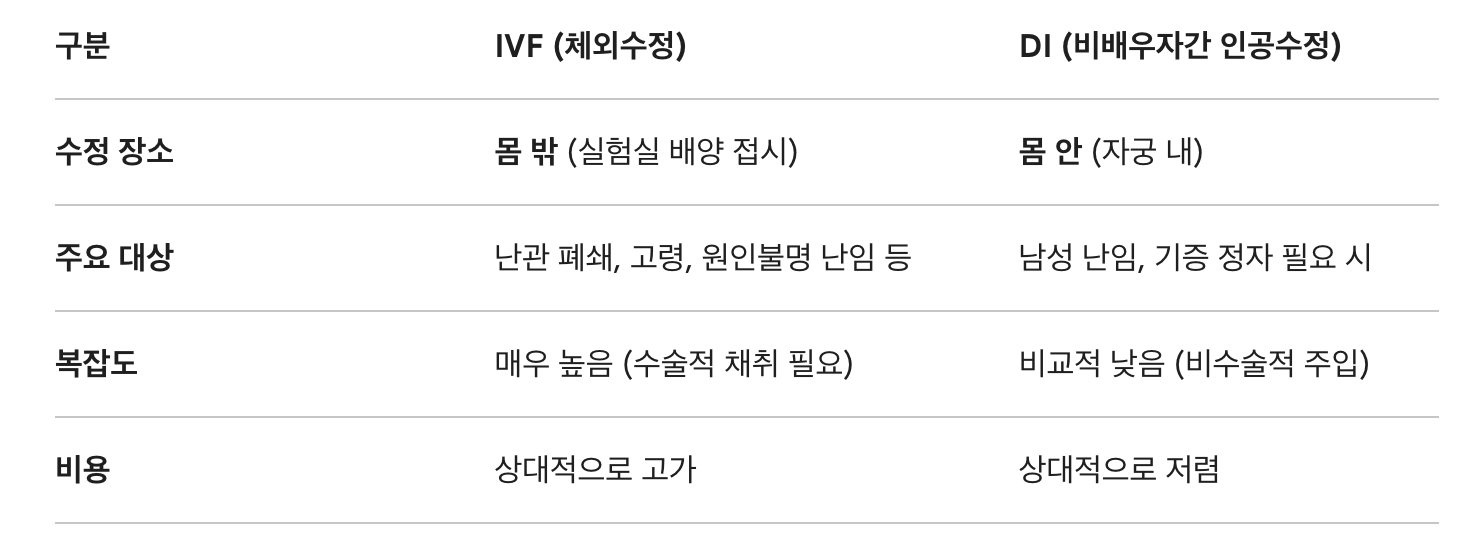


In [7]:
pd.crosstab(df['시술 유형'], df['임신 성공 여부'], normalize='index')

임신 성공 여부,0,1
시술 유형,,
DI,0.871086,0.128914
IVF,0.738395,0.261605


In [8]:
# 결측 비율 보기
missing_ratio = df.isnull().mean().sort_values(ascending=False)
missing_ratio.head(20)

난자 해동 경과일                0.994398
PGS 시술 여부                0.992475
PGD 시술 여부                0.991500
착상 전 유전 검사 사용 여부         0.989397
임신 시도 또는 마지막 임신 경과 연수    0.963449
배아 해동 경과일                0.842525
난자 채취 경과일                0.224255
난자 혼합 경과일                0.209615
배아 이식 경과일                0.169947
총 생성 배아 수                0.024541
저장된 신선 난자 수              0.024541
기증자 정자와 혼합된 난자 수         0.024541
파트너 정자와 혼합된 난자 수         0.024541
혼합된 난자 수                 0.024541
해동 난자 수                  0.024541
수집된 신선 난자 수              0.024541
이식된 배아 수                 0.024541
배아 생성 주요 이유              0.024541
해동된 배아 수                 0.024541
미세주입 배아 이식 수             0.024541
dtype: float64

난자 해동 경과일 → 99.4% 결측
PGS → 99.2% 결측
PGD → 99.1% 결측       ---> 대부분의 환자가 해당 시술을 안했음을 알 수 있음

In [9]:
# 결측치 vs 타겟 관계 보기
df['PGS 시술 여부'].isnull().groupby(df['임신 성공 여부']).mean()

임신 성공 여부
0    0.991947
1    0.993990
Name: PGS 시술 여부, dtype: float64

PGS 시술 여부는 결측 비율이 매우 높고,
결측 여부와 임신 성공 간 차이도 거의 없어서
예측 변수로서 영향력은 크지 않을 가능성

In [10]:
# 컬럼명 전체 확인
df.columns.tolist()

['ID',
 '시술 시기 코드',
 '시술 당시 나이',
 '임신 시도 또는 마지막 임신 경과 연수',
 '시술 유형',
 '특정 시술 유형',
 '배란 자극 여부',
 '배란 유도 유형',
 '단일 배아 이식 여부',
 '착상 전 유전 검사 사용 여부',
 '착상 전 유전 진단 사용 여부',
 '남성 주 불임 원인',
 '남성 부 불임 원인',
 '여성 주 불임 원인',
 '여성 부 불임 원인',
 '부부 주 불임 원인',
 '부부 부 불임 원인',
 '불명확 불임 원인',
 '불임 원인 - 난관 질환',
 '불임 원인 - 남성 요인',
 '불임 원인 - 배란 장애',
 '불임 원인 - 여성 요인',
 '불임 원인 - 자궁경부 문제',
 '불임 원인 - 자궁내막증',
 '불임 원인 - 정자 농도',
 '불임 원인 - 정자 면역학적 요인',
 '불임 원인 - 정자 운동성',
 '불임 원인 - 정자 형태',
 '배아 생성 주요 이유',
 '총 시술 횟수',
 '클리닉 내 총 시술 횟수',
 'IVF 시술 횟수',
 'DI 시술 횟수',
 '총 임신 횟수',
 'IVF 임신 횟수',
 'DI 임신 횟수',
 '총 출산 횟수',
 'IVF 출산 횟수',
 'DI 출산 횟수',
 '총 생성 배아 수',
 '미세주입된 난자 수',
 '미세주입에서 생성된 배아 수',
 '이식된 배아 수',
 '미세주입 배아 이식 수',
 '저장된 배아 수',
 '미세주입 후 저장된 배아 수',
 '해동된 배아 수',
 '해동 난자 수',
 '수집된 신선 난자 수',
 '저장된 신선 난자 수',
 '혼합된 난자 수',
 '파트너 정자와 혼합된 난자 수',
 '기증자 정자와 혼합된 난자 수',
 '난자 출처',
 '정자 출처',
 '난자 기증자 나이',
 '정자 기증자 나이',
 '동결 배아 사용 여부',
 '신선 배아 사용 여부',
 '기증 배아 사용 여부',
 '대리모 여부',
 'PGD 시술 여부',
 'PGS 시술 여부',
 '난자 채취 경과일',
 '난자 해동 경과일',
 '난자

In [11]:
# 의미있는 변수 찾기
import pandas as pd

cols = [
    '시술 유형',
    '특정 시술 유형',
    '시술 당시 나이',
    '단일 배아 이식 여부',
    '배아 생성 주요 이유'
]

for col in cols:
    print(f"\n===== {col} =====")
    print(pd.crosstab(df[col], df['임신 성공 여부'], normalize='index'))


===== 시술 유형 =====
임신 성공 여부         0         1
시술 유형                       
DI        0.871086  0.128914
IVF       0.738395  0.261605

===== 특정 시술 유형 =====
임신 성공 여부                                    0         1
특정 시술 유형                                               
FER                                  0.666667  0.333333
GIFT                                 1.000000  0.000000
Generic DI                           0.830986  0.169014
ICI                                  0.864583  0.135417
ICSI                                 0.727175  0.272825
ICSI / AH                            0.782835  0.217165
ICSI / AH:Unknown                    0.500000  0.500000
ICSI / BLASTOCYST                    0.643257  0.356743
ICSI / BLASTOCYST :ICSI              0.000000  1.000000
ICSI / BLASTOCYST :IVF / BLASTOCYST  0.750000  0.250000
ICSI / BLASTOCYST:IVF / BLASTOCYST   0.666667  0.333333
ICSI:ICSI                            0.990061  0.009939
ICSI:IVF                             0.765178  0.234822
ICS

In [12]:
# 나이 따로보자
print(pd.crosstab(df['시술 당시 나이'], df['임신 성공 여부'], normalize='index'))

임신 성공 여부         0         1
시술 당시 나이                    
만18-34세   0.677378  0.322622
만35-37세   0.721599  0.278401
만38-39세   0.782862  0.217138
만40-42세   0.840607  0.159393
만43-44세   0.881988  0.118012
만45-50세   0.832321  0.167679
알 수 없음    1.000000  0.000000


In [13]:
# 시술 횟수 vs 성공
print(pd.crosstab(df['총 시술 횟수'], df['임신 성공 여부'], normalize='index').head(10))

임신 성공 여부         0         1
총 시술 횟수                     
0회        0.709013  0.290987
1회        0.750048  0.249952
2회        0.755834  0.244166
3회        0.763646  0.236354
4회        0.772208  0.227792
5회        0.784208  0.215792
6회 이상     0.796700  0.203300


In [14]:
# 배아 관련
print(pd.crosstab(df['이식된 배아 수'], df['임신 성공 여부'], normalize='index'))

임신 성공 여부         0         1
이식된 배아 수                    
0.0       0.999179  0.000821
1.0       0.686452  0.313548
2.0       0.688908  0.311092
3.0       0.831532  0.168468


In [15]:
# 상관관계
corr = df.corr(numeric_only=True)['임신 성공 여부'].sort_values(ascending=False)
print(corr.head(10))

임신 성공 여부            1.000000
이식된 배아 수            0.157487
배아 이식 경과일           0.148590
총 생성 배아 수           0.146116
단일 배아 이식 여부         0.132635
혼합된 난자 수            0.116136
파트너 정자와 혼합된 난자 수    0.104902
미세주입에서 생성된 배아 수     0.090275
수집된 신선 난자 수         0.083023
미세주입 배아 이식 수        0.074351
Name: 임신 성공 여부, dtype: float64


In [16]:
print(pd.crosstab(df['시술 유형'], df['임신 성공 여부'], normalize='index'))

임신 성공 여부         0         1
시술 유형                       
DI        0.871086  0.128914
IVF       0.738395  0.261605


In [17]:
pd.crosstab(df['정자 출처'], df['임신 성공 여부'], normalize='index')

임신 성공 여부,0,1
정자 출처,,
기증 제공,0.756256,0.243744
미할당,0.893443,0.106557
배우자 및 기증 제공,1.000000,0.000000
배우자 제공,0.739833,0.260167


1. 미할당 → 성공 10.6% (매우 낮음) - 미할당 의미는 진짜 결측치 가능성 높음(기록누착,시스템 문제 등), 특수 케이스(시술 중단,데이터 incomplete,실험/비정형 케이스)나 임상적으로 복잡한 케이스 등으로 추정 ---->미할당 카테고리는 실제 임상적 의미보다는
데이터 누락 또는 기록 문제일 가능성이 있어서
별도로 처리하거나 제외 검토가 필요해 보임
2. 배우자 및 기증 제공 카테고리는 샘플 수가 매우 적어서
통계적으로 의미 있는 패턴으로 보기 어렵고,
모델에서는 별도 처리 또는 통합이 필요해보임

In [18]:
# 불임 원인 그룹
cols = [c for c in df.columns if '불임 원인' in c]

for col in cols:
    print(f"\n===== {col} =====")
    print(pd.crosstab(df[col], df['임신 성공 여부'], normalize='index'))


===== 남성 주 불임 원인 =====
임신 성공 여부           0         1
남성 주 불임 원인                    
0           0.740525  0.259475
1           0.780027  0.219973

===== 남성 부 불임 원인 =====
임신 성공 여부           0         1
남성 부 불임 원인                    
0           0.740842  0.259158
1           0.802499  0.197501

===== 여성 주 불임 원인 =====
임신 성공 여부           0         1
여성 주 불임 원인                    
0           0.740408  0.259592
1           0.780853  0.219147

===== 여성 부 불임 원인 =====
임신 성공 여부           0         1
여성 부 불임 원인                    
0           0.740864  0.259136
1           0.804205  0.195795

===== 부부 주 불임 원인 =====
임신 성공 여부           0         1
부부 주 불임 원인                    
0           0.740348  0.259652
1           0.779757  0.220243

===== 부부 부 불임 원인 =====
임신 성공 여부           0         1
부부 부 불임 원인                    
0           0.741019  0.258981
1           0.813084  0.186916

===== 불명확 불임 원인 =====
임신 성공 여부          0         1
불명확 불임 원인                    
0          0.742024  0.257976

1. 기본 성공율 :  약 25~26% (대부분 변수에서 0일때,25.8% 정도)

In [19]:
df[['여성 주 불임 원인','여성 부 불임 원인','남성 주 불임 원인','남성 부 불임 원인']].sum()

여성 주 불임 원인    7876
여성 부 불임 원인    3187
남성 주 불임 원인    7310
남성 부 불임 원인    3362
dtype: int64

In [20]:
df[['여성 주 불임 원인','여성 부 불임 원인','남성 주 불임 원인','남성 부 불임 원인']].head(20)

,여성 주 불임 원인,여성 부 불임 원인,남성 주 불임 원인,남성 부 불임 원인
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0
5,0,0,0,0
6,0,0,0,0
7,0,0,0,0
8,0,0,0,0
9,0,0,0,0


In [21]:
df['불임 원인 개수'] = (
    df['남성 주 불임 원인'] +
    df['남성 부 불임 원인'] +
    df['여성 주 불임 원인'] +
    df['여성 부 불임 원인'] +
    df['부부 주 불임 원인'] +
    df['부부 부 불임 원인']
)

In [22]:
pd.crosstab(df['불명확 불임 원인'], df['임신 성공 여부'], normalize='index')

임신 성공 여부,0,1
불명확 불임 원인,,
0,0.742024,0.257976
1,0.740537,0.259463


불명확 불임 원인
0 → 성공 25.8%

1 → 성공 25.9%

In [23]:
df[
    (df['여성 주 불임 원인']==0) &
    (df['남성 주 불임 원인']==0) &
    (df['부부 주 불임 원인']==0)
]['불명확 불임 원인'].value_counts()

불명확 불임 원인
0    184954
1     62344
Name: count, dtype: int64

주 원인 (여성/남성/부부) 다 0인 경우
→ 불명확 불임 원인 = 1도 꽤 많음

0 = “원인 없음” + “기록 없음” + “기타”

불명확 불임 원인은 임신 성공률에 큰 차이를 보이지 않았으며,
주요 불임 원인 변수들과의 관계를 보면
0 값이 단순히 ‘원인 없음’을 의미하기보다는
기록 누락 또는 정의상의 한계가 포함된 값일 가능성이 있음

In [24]:
cols = [
    '여성 주 불임 원인',
    '여성 부 불임 원인',
    '남성 주 불임 원인',
    '남성 부 불임 원인',
    '부부 주 불임 원인',
    '부부 부 불임 원인'
]

df[cols] = df[cols].fillna(0)
df['불임 원인 개수'] = df[cols].sum(axis=1)

pd.crosstab(df['불임 원인 개수'], df['임신 성공 여부'], normalize='index')

임신 성공 여부,0,1
불임 원인 개수,,
0,0.739585,0.260415
1,0.800000,0.200000
2,0.748000,0.252000
3,0.787562,0.212438
4,0.800000,0.200000
6,1.000000,0.000000


불임 원인 갯수와 임신 성공여부는 선형관계가 아님.
1. 데이터 정의 :  0이 원인없음만을 의미하는게 아니라 기록없음이 포함되므로
2. 원인의 질quality  더 중요 : 개수보다는 종류(질)
3. 샘플 수 부족: 4개 6개 그룹은 샘플 수 매우 적어 노이즈임
--> 불임 원인 갯수 보다는 원인의 종류와 치료 가능성이 더 중요한 요인일 가능성을 시사함


In [25]:
cols = [
    '불임 원인 - 남성 요인',
    '불임 원인 - 배란 장애',
    '불임 원인 - 난관 질환'
]

for col in cols:
    print(col)
    print(pd.crosstab(df[col], df['임신 성공 여부'], normalize='index'))
    print('-'*30)

불임 원인 - 남성 요인
임신 성공 여부              0         1
불임 원인 - 남성 요인                    
0              0.754433  0.245567
1              0.720110  0.279890
------------------------------
불임 원인 - 배란 장애
임신 성공 여부              0         1
불임 원인 - 배란 장애                    
0              0.745892  0.254108
1              0.713367  0.286633
------------------------------
불임 원인 - 난관 질환
임신 성공 여부              0         1
불임 원인 - 난관 질환                    
0              0.741555  0.258445
1              0.742245  0.257755
------------------------------


남성 요인

0 → 24.6%

1 → 27.9%

배란 장애

0 → 25.4%

1 → 28.6%

난관 질환

0 → 25.8%

1 → 25.7%
 1. 남성 요인이 있을 때 임신 성공율이 높다는 것은 치료가 잘되는 문제라는 뜻임
 2. 배란 장애 시 임신 성공율이 높다는 것은 치료가 잘되는 문제라는 뜻임
 “치료 가능한 불임 원인 → 성공률 높음”

 3. 그러나 난관 질환은 임신 성공율에 별 차이가 없어 변수 중요도가 낮을 가능성이 큼

In [26]:
pd.crosstab(df['배란 유도 유형'], df['임신 성공 여부'], normalize='index')

임신 성공 여부,0,1
배란 유도 유형,,
기록되지 않은 시행,0.731593,0.268407
생식선 자극 호르몬,0.000000,1.000000
세트로타이드 (억제제),1.000000,0.000000
알 수 없음,0.773245,0.226755


In [27]:
df['배란 유도 유형'].value_counts()

배란 유도 유형
기록되지 않은 시행      194432
알 수 없음           61917
세트로타이드 (억제제)         1
생식선 자극 호르몬           1
Name: count, dtype: int64

In [28]:
pd.crosstab(df['단일 배아 이식 여부'], df['임신 성공 여부'], normalize='index')

임신 성공 여부,0,1
단일 배아 이식 여부,,
0.0,0.770567,0.229433
1.0,0.632770,0.367230


단일 배아 이식 여부

0 → 성공률 22.9%

1 → 성공률 36.7%

단일 배아 이식이 성공률 높게 나오냐

이유 1: 좋은 환자에게 선택됨

젊은 환자,
배아 quality 좋은 경우

그래서 이미 성공 가능성이 높은 그룹  -> 이것은 '원인'이 아니라 '선택결과'에 가까움
단일 배아 이식 여부 = 강력한 예측 변수 (하지만 인과 아님)
====이건 data leakage는 아니지만 post-decision bias 가능성 있음

EDA 잠시 중지  BASELINE MODEL  시작

In [29]:
# 베이스라인 모델 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [30]:
import pandas as pd

df = pd.read_csv('data/train.csv')
# ==============================
# 🔥 숫자 변환 (여기!)
# ==============================
df['총 시술 횟수'] = df['총 시술 횟수'].astype(str).str.extract(r'(\d+)')
df['총 임신 횟수'] = df['총 임신 횟수'].astype(str).str.extract(r'(\d+)')

df['총 시술 횟수'] = pd.to_numeric(df['총 시술 횟수'], errors='coerce')
df['총 임신 횟수'] = pd.to_numeric(df['총 임신 횟수'], errors='coerce')

In [31]:
# ======================
# BASELINE MODEL LOGISTIC REGRESSION (리더보드점수: 0.72381)
# ======================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

df_model = df.copy()

X = df_model.drop(columns=['임신 성공 여부', 'ID'])
y = df_model['임신 성공 여부']

# 범주형 인코딩
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# 결측치 처리
X = X.fillna(-1)

# 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 모델
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 평가
pred = model.predict_proba(X_val)[:, 1]
print("AUC:", roc_auc_score(y_val, pred))

AUC: 0.7217431512237072


In [32]:
import pandas as pd

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [33]:
X = train.drop(columns=['임신 성공 여부', 'ID'])
y = train['임신 성공 여부']

X_test = test.drop(columns=['ID'])

In [34]:
X = pd.get_dummies(X)
X_test = pd.get_dummies(X_test)

# 컬럼 맞추기 (핵심)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

In [35]:
X = X.fillna(0)
X_test = X_test.fillna(0)

In [36]:
print(X.isnull().sum().sum())

0


In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
pred = model.predict_proba(X_test)[:, 1]

In [39]:
submission = pd.read_csv('data/sample_submission.csv')

In [40]:
submission['probability'] = pred

In [41]:
submission.to_csv('submission_lr_baseline.csv', index=False)

In [42]:
print(pred[:10])


[0.04326266 0.06183752 0.24579014 0.11701394 0.49080721 0.1378237
 0.47407254 0.2371797  0.28170587 0.02673346]


In [43]:
print(submission.columns)

Index(['ID', 'probability'], dtype='object')


EDA 다시 시작

In [44]:
for col in train.columns:
    print(col)

ID
시술 시기 코드
시술 당시 나이
임신 시도 또는 마지막 임신 경과 연수
시술 유형
특정 시술 유형
배란 자극 여부
배란 유도 유형
단일 배아 이식 여부
착상 전 유전 검사 사용 여부
착상 전 유전 진단 사용 여부
남성 주 불임 원인
남성 부 불임 원인
여성 주 불임 원인
여성 부 불임 원인
부부 주 불임 원인
부부 부 불임 원인
불명확 불임 원인
불임 원인 - 난관 질환
불임 원인 - 남성 요인
불임 원인 - 배란 장애
불임 원인 - 여성 요인
불임 원인 - 자궁경부 문제
불임 원인 - 자궁내막증
불임 원인 - 정자 농도
불임 원인 - 정자 면역학적 요인
불임 원인 - 정자 운동성
불임 원인 - 정자 형태
배아 생성 주요 이유
총 시술 횟수
클리닉 내 총 시술 횟수
IVF 시술 횟수
DI 시술 횟수
총 임신 횟수
IVF 임신 횟수
DI 임신 횟수
총 출산 횟수
IVF 출산 횟수
DI 출산 횟수
총 생성 배아 수
미세주입된 난자 수
미세주입에서 생성된 배아 수
이식된 배아 수
미세주입 배아 이식 수
저장된 배아 수
미세주입 후 저장된 배아 수
해동된 배아 수
해동 난자 수
수집된 신선 난자 수
저장된 신선 난자 수
혼합된 난자 수
파트너 정자와 혼합된 난자 수
기증자 정자와 혼합된 난자 수
난자 출처
정자 출처
난자 기증자 나이
정자 기증자 나이
동결 배아 사용 여부
신선 배아 사용 여부
기증 배아 사용 여부
대리모 여부
PGD 시술 여부
PGS 시술 여부
난자 채취 경과일
난자 해동 경과일
난자 혼합 경과일
배아 이식 경과일
배아 해동 경과일
임신 성공 여부


In [45]:
[col for col in train.columns if '착상' in col]

['착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부']

In [ ]:
train['유전검사여부'] = (
    (train['착상 전 유전 검사 사용 여부'] == 1) |
    (train['착상 전 유전 진단 사용 여부'] == 1)
).astype(int)

test['유전검사여부'] = (
    (test['착상 전 유전 검사 사용 여부'] == 1) |
    (test['착상 전 유전 진단 사용 여부'] == 1)
).astype(int)

In [46]:
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

In [47]:
train['유전검사여부'] = (
    (train['착상 전 유전 검사 사용 여부'] == 1) |
    (train['착상 전 유전 진단 사용 여부'] == 1)
).astype(int)

test['유전검사여부'] = (
    (test['착상 전 유전 검사 사용 여부'] == 1) |
    (test['착상 전 유전 진단 사용 여부'] == 1)
).astype(int)

In [48]:
print(train.columns)

Index(['ID', '시술 시기 코드', '시술 당시 나이', '임신 시도 또는 마지막 임신 경과 연수', '시술 유형',
       '특정 시술 유형', '배란 자극 여부', '배란 유도 유형', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부',
       '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인',
       '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환',
       '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제',
       '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인',
       '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '배아 생성 주요 이유', '총 시술 횟수',
       '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수',
       'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '총 생성 배아 수',
       '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수',
       '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수',
       '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '난자 출처', '정자 출처',
       '난자 기증자 나이', '정자 기증자 나이', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부',
       '대리모 여부', 'PGD 시술 여부', 'PGS 시술 여부

유전검사여부 = 0 → 성공률 26.0%
유전검사여부 = 1 → 성공률 17.2%

오히려 유전검사 하면 성공률 낮음
이게 의미하는 것

이거 중요한데 유전검사 자체가 나쁜 게 아니라 “어려운 케이스가 유전검사를 받는다” (selection bias)

In [49]:
# import + df 로드
import pandas as pd
import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

df = pd.read_csv("data/train.csv")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [50]:
# 함수 셀
def run_model(cols):
    df_model = df[cols + ['임신 성공 여부']].copy()

    X = df_model.drop(columns=['임신 성공 여부'])
    y = df_model['임신 성공 여부']

    X = pd.get_dummies(X)
    X = X.fillna(0)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    with mlflow.start_run():
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)

        pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, pred)

        mlflow.log_param("features", str(cols))
        mlflow.log_metric("auc", auc)

    print("AUC:", auc)

In [51]:
cols = [
    '시술 당시 나이',
    '시술 유형',
    '단일 배아 이식 여부',
    '총 시술 횟수',
    'IVF 시술 횟수',
    '총 임신 횟수',
    '총 출산 횟수',
    '불임 원인 - 남성 요인',
    '불임 원인 - 배란 장애',
    '불임 원인 - 난관 질환'
]

run_model(cols)

AUC: 0.6273696638028396


In [52]:
cols = [
    '시술 당시 나이',
    '시술 유형',
    '단일 배아 이식 여부',

    # 🔥 핵심 추가
    '이식된 배아 수',
    '총 생성 배아 수',
    '미세주입된 난자 수',

    '총 시술 횟수',
    '총 임신 횟수',
    '총 출산 횟수',

    '불임 원인 - 남성 요인',
    '불임 원인 - 배란 장애',
    '불임 원인 - 난관 질환',

    # 🔥 추가
    '배란 자극 여부',
    '동결 배아 사용 여부',
    '신선 배아 사용 여부'
]
run_model(cols)

AUC: 0.6976549466063862


In [53]:
best_cols = cols

In [54]:
test_cols = best_cols + ['배란 유도 유형']
run_model(test_cols)

AUC: 0.6981816946363573


In [55]:
best_cols = test_cols

In [56]:
test_cols = best_cols + ['이식된 배아 수']
run_model(test_cols)

AUC: 0.6982350698852633


In [57]:
best_cols = test_cols

In [58]:
test_cols = best_cols + ['총 생성 배아 수']
run_model(test_cols)

AUC: 0.698286616589152


In [59]:
best_cols = test_cols

In [60]:
test_cols = best_cols + ['미세주입된 난자 수']
run_model(test_cols)

AUC: 0.6981108777284111


In [61]:
test_cols = best_cols + ['미세주입에서 생성된 배아 수']
run_model(test_cols)

AUC: 0.6984586497177816


In [62]:
best_cols = test_cols

In [63]:
# ratio feature 만들기
df['배아 생성 효율'] = df['총 생성 배아 수'] / (df['미세주입된 난자 수'] + 1)

In [64]:
test_cols = best_cols + ['배아 생성 효율']
run_model(test_cols)

AUC: 0.6984593604877232


In [65]:
best_cols = test_cols

In [66]:
# 두번째 ratio
df['이식 효율'] = df['이식된 배아 수'] / (df['총 생성 배아 수'] + 1)

In [67]:
test_cols = best_cols + ['이식 효율']
run_model(test_cols)

AUC: 0.6993770716933587


In [68]:
best_cols = test_cols

In [69]:
df['총 임신 횟수'] = pd.to_numeric(df['총 임신 횟수'], errors='coerce')
df['총 시술 횟수'] = pd.to_numeric(df['총 시술 횟수'], errors='coerce')

In [70]:
df['임신 성공 효율'] = df['총 임신 횟수'] / (df['총 시술 횟수'] + 1)

In [71]:
test_cols = best_cols + ['임신 성공 효율']
run_model(test_cols)

AUC: 0.6979052795812573


In [72]:
best_cols = test_cols

In [73]:
df['출산 성공 효율'] = df['총 출산 횟수'] / (df['총 임신 횟수'] + 1)

In [74]:
test_cols = best_cols + ['출산 성공 효율']
run_model(test_cols)

AUC: 0.6979052795812573


In [75]:
df['IVF 시술 횟수'] = pd.to_numeric(df['IVF 시술 횟수'], errors='coerce')

df['IVF 여부'] = (df['IVF 시술 횟수'] > 0).astype(int)

test_cols = best_cols + ['IVF 여부']
run_model(test_cols)

AUC: 0.6979361802051961


In [76]:
# 숫자 변환 (안전)
df['시술 당시 나이'] = pd.to_numeric(df['시술 당시 나이'], errors='coerce')
df['IVF 시술 횟수'] = pd.to_numeric(df['IVF 시술 횟수'], errors='coerce')

# interaction
df['나이_IVF'] = df['시술 당시 나이'] * df['IVF 시술 횟수']

In [77]:
test_cols = best_cols + ['나이_IVF']
run_model(test_cols)

AUC: 0.6701740562419548


In [78]:
# 실패 경험 feature
df['임신-출산 차이'] = df['총 임신 횟수'] - df['총 출산 횟수']

test_cols = best_cols + ['임신-출산 차이']
run_model(test_cols)

AUC: 0.6702064478944582


In [79]:
import numpy as np

df['총 시술 횟수'] = pd.to_numeric(df['총 시술 횟수'], errors='coerce')
df['총 시술 횟수_log'] = np.log1p(df['총 시술 횟수'])

test_cols = best_cols + ['총 시술 횟수_log']
run_model(test_cols)

AUC: 0.6701740562419548


In [80]:
test_cols = best_cols + [
    '이식된 배아 수',
    '총 생성 배아 수',
    '미세주입된 난자 수',
    '배란 자극 여부',
    '동결 배아 사용 여부',
    '신선 배아 사용 여부'
]

run_model(test_cols)

AUC: 0.6702636906848339


In [81]:
test_cols = best_cols + ['이식된 배아 수']
run_model(test_cols)

AUC: 0.6701612286313618


In [82]:
test_cols = best_cols + ['총 생성 배아 수']
run_model(test_cols)

AUC: 0.6701950795461753


In [83]:
test_cols = best_cols + ['미세주입된 난자 수']
run_model(test_cols)

AUC: 0.6701558164557735


In [84]:
test_cols = best_cols + ['총 생성 배아 수']
run_model(test_cols)

AUC: 0.6701950795461753


In [85]:
test_cols = best_cols + ['배란 자극 여부']
run_model(test_cols)

AUC: 0.6701789998652912


In [86]:
test_cols = best_cols + ['동결 배아 사용 여부']
run_model(test_cols)

AUC: 0.670155063992623


In [87]:
test_cols = best_cols + ['신선 배아 사용 여부']
run_model(test_cols)

AUC: 0.6701990781234443


In [88]:
df.groupby('시술 유형')['임신 성공 여부'].mean().sort_values(ascending=False)

시술 유형
IVF    0.261605
DI     0.128914
Name: 임신 성공 여부, dtype: float64

In [89]:
df['IVF_only'] = (df['시술 유형'] == 'IVF').astype(int)

In [90]:
df['IVF_나이'] = df['IVF_only'] * df['시술 당시 나이']

In [91]:
test_cols = best_cols + ['IVF_only', 'IVF_나이']
run_model(test_cols)

AUC: 0.6701804492006469


In [92]:
# 임신 성공률 (과거 기준)
df['과거 성공률'] = df['총 출산 횟수'] / (df['총 임신 횟수'] + 1)

test_cols = best_cols + ['과거 성공률']
run_model(test_cols)

AUC: 0.6702064478944582


In [93]:
# IVF 집중도
df['IVF 비율'] = df['IVF 시술 횟수'] / (df['총 시술 횟수'] + 1)

test_cols = best_cols + ['IVF 비율']
run_model(test_cols)

AUC: 0.6701740562419548


In [94]:
df['총 출산 횟수'] = pd.to_numeric(df['총 출산 횟수'], errors='coerce')
df['총 생성 배아 수'] = pd.to_numeric(df['총 생성 배아 수'], errors='coerce')

In [95]:
df['배아 대비 출산'] = df['총 출산 횟수'] / (df['총 생성 배아 수'] + 1)

test_cols = best_cols + ['배아 대비 출산']
run_model(test_cols)

AUC: 0.6695242348229027


In [96]:
test_cols = best_cols + [
    '이식된 배아 수',
    '총 생성 배아 수'
]
run_model(test_cols)

AUC: 0.6695259938792384


In [97]:
test_cols = best_cols + [
    '미세주입된 난자 수',
    '총 생성 배아 수'
]
run_model(test_cols)

AUC: 0.6695373820814302


In [98]:
test_cols = best_cols + [
    '배란 자극 여부',
    'IVF 여부'
]
run_model(test_cols)

AUC: 0.6695594814675175


변수 하나씩 추가하고, 조합을 다 해보아도 성능이 0.66-0.07 사이로 오르지 않아서
CATBOOST모델로 가기로 한다. 

In [99]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [100]:
num_cols = [
    '총 생성 배아 수',
    '미세주입된 난자 수',
    '이식된 배아 수',
    '총 임신 횟수',
    '총 시술 횟수'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 확인 (중요)
print(df[num_cols].dtypes)

총 생성 배아 수     float64
미세주입된 난자 수    float64
이식된 배아 수      float64
총 임신 횟수       float64
총 시술 횟수       float64
dtype: object


In [101]:
df['배아 생성 효율'] = df['총 생성 배아 수'] / (df['미세주입된 난자 수'] + 1)

df['이식 효율'] = df['이식된 배아 수'] / (df['총 생성 배아 수'] + 1)

df['임신 성공 효율'] = df['총 임신 횟수'] / (df['총 시술 횟수'] + 1)

In [102]:
print(df[['총 임신 횟수', '총 시술 횟수']].head())

   총 임신 횟수  총 시술 횟수
0      NaN      NaN
1      NaN      NaN
2      NaN      NaN
3      NaN      NaN
4      NaN      NaN


In [103]:
print(df['총 시술 횟수'].unique()[:20])

[nan]


In [104]:
# ==============================
# 1️⃣ 라이브러리
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from catboost import CatBoostClassifier


# ==============================
# 2️⃣ 데이터 로드
# ==============================
df = pd.read_csv("data/train.csv")


# ==============================
# 3️⃣ 숫자 자동 변환 (🔥 핵심)
# ==============================
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')


# ==============================
# 4️⃣ CatBoost 실행 함수
# ==============================
def run_catboost(cols):
    
    # 모델용 데이터
    df_model = df[cols + ['임신 성공 여부']].copy()

    X = df_model.drop(columns=['임신 성공 여부'])
    y = df_model['임신 성공 여부']

    # 원핫 인코딩
    X = pd.get_dummies(X)

    # 결측치 처리
    X = X.fillna(0)

    # train / validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # ==============================
    # 5️⃣ 모델
    # ==============================
    model = CatBoostClassifier(
        depth=6,
        learning_rate=0.05,
        iterations=500,
        verbose=0
    )

    # 학습
    model.fit(X_train, y_train)

    # 예측
    pred = model.predict_proba(X_val)[:, 1]

    # 평가
    auc = roc_auc_score(y_val, pred)

    print("🔥 CATBOOST AUC:", auc)


# ==============================
# 6️⃣ 실행
# ==============================
run_catboost(best_cols)

/var/folders/nv/z6pqq3dd2lv0_6pz5fwk1zcw0000gn/T/ipykernel_75837/206581578.py:23: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


KeyError: "['배아 생성 효율', '이식 효율', '임신 성공 효율'] not in index"

In [105]:
print(df['총 시술 횟수'].head())
print(df['총 임신 횟수'].head())

0    0회
1    0회
2    1회
3    1회
4    0회
Name: 총 시술 횟수, dtype: object
0    0회
1    0회
2    0회
3    0회
4    0회
Name: 총 임신 횟수, dtype: object


In [ ]:
# =========================================
# 🔥 CLEAN START (여기부터 진짜)
# =========================================

In [106]:
import pandas as pd
import numpy as np

# 1. 데이터 로드
df = pd.read_csv('data/train.csv')

# 2. 숫자 변환 (핵심)
df['총 시술 횟수'] = df['총 시술 횟수'].astype(str).str.replace('회','')
df['총 임신 횟수'] = df['총 임신 횟수'].astype(str).str.replace('회','')

df['총 시술 횟수'] = pd.to_numeric(df['총 시술 횟수'], errors='coerce')
df['총 임신 횟수'] = pd.to_numeric(df['총 임신 횟수'], errors='coerce')

# 확인
print(df['총 시술 횟수'].head())
print(df['총 임신 횟수'].head())

0    0.0
1    0.0
2    1.0
3    1.0
4    0.0
Name: 총 시술 횟수, dtype: float64
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: 총 임신 횟수, dtype: float64


In [107]:
print(df['총 임신 횟수'].value_counts().head(10))

총 임신 횟수
0.0    205426
1.0     43829
2.0      6246
3.0       746
4.0        93
5.0         8
Name: count, dtype: int64


In [108]:
import mlflow

df = mlflow.search_runs()

print(df.head())

                             run_id experiment_id    status  \
0  0785bff85a2d491c89a4200d80059dcc             0  FINISHED   
1  bcf9b595282245f0a2b9a3152043d69e             0  FINISHED   
2  ca008dd50f374494b417b08b21963fc0             0  FINISHED   
3  c6390099026444dfb21fbc7f444ac267             0  FINISHED   
4  3346f5a5fc874944984b65f43980eab6             0  FINISHED   

                                        artifact_uri  \
0  mlflow-artifacts:/0/0785bff85a2d491c89a4200d80...   
1  mlflow-artifacts:/0/bcf9b595282245f0a2b9a31520...   
2  mlflow-artifacts:/0/ca008dd50f374494b417b08b21...   
3  mlflow-artifacts:/0/c6390099026444dfb21fbc7f44...   
4  mlflow-artifacts:/0/3346f5a5fc874944984b65f439...   

                        start_time                         end_time  \
0 2026-04-23 14:00:20.042000+00:00 2026-04-23 14:00:21.320000+00:00   
1 2026-04-23 14:00:18.588000+00:00 2026-04-23 14:00:19.892000+00:00   
2 2026-04-23 14:00:17.088000+00:00 2026-04-23 14:00:18.441000+00:00   


In [111]:
print(df.columns)

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.auc', 'params.features', 'tags.mlflow.user',
       'tags.mlflow.runName', 'tags.mlflow.source.type',
       'tags.mlflow.source.git.commit', 'tags.mlflow.source.name'],
      dtype='object')


In [112]:
print(df[[
    "run_id",
    "metrics.auc",
    "params.features"
]])

                              run_id  metrics.auc  \
0   0785bff85a2d491c89a4200d80059dcc     0.669559   
1   bcf9b595282245f0a2b9a3152043d69e     0.669537   
2   ca008dd50f374494b417b08b21963fc0     0.669526   
3   c6390099026444dfb21fbc7f444ac267     0.669524   
4   3346f5a5fc874944984b65f43980eab6     0.670174   
5   d22caa1da6b34e4e9d796d7074b7dc14     0.670206   
6   ca6687a00c884a9ca2ad055001f0fc10     0.670180   
7   e47e1220a3d74a3796dce62513b91fb2     0.670199   
8   8c8f28b49ebb4b0cbf92a937142958e7     0.670155   
9   c5069d9f77444bfbb6f886457eb61e76     0.670179   
10  594e4f3a077a4460845a20cc3656f0b4     0.670195   
11  48afbb4b94044c37890f9be34f78e0d5     0.670156   
12  f2754d201c754fd4a0d31c6961dfe3d5     0.670195   
13  f91c0bf1d1c04281b8c627eb6f30f9ea     0.670161   
14  f28e1ccb6a394ecb979cdba2d02a421a     0.670264   
15  fb943ead504c45aeba73a73116f0c127     0.670174   
16  f7873af40fdd4c9fb1689ca8a5ea653f     0.670206   
17  c8664af32f954b4c8252203c6ae021d9     0.670

In [113]:
df_sorted = df.sort_values("metrics.auc", ascending=False)

print(df_sorted[[
    "run_id",
    "metrics.auc",
    "params.features"
]])

                              run_id  metrics.auc  \
21  092fa48552234204a537d3204f50ee46     0.699377   
22  5344d2c4bede4b7a92e5aad12f665518     0.698459   
23  68f1596c99174207b507c9ae16f018ea     0.698459   
25  4ceb75c492aa432fa0ea82af4ee66b1f     0.698287   
26  5c6219e43fe34ec5b2f3c182d9298da8     0.698235   
27  69edf06d0894410d8d02de04b5cf6eff     0.698182   
24  f84c03c2291c425484991a1ac49af2fe     0.698111   
18  9c723716ef0c43a3989b4b29da28851a     0.697936   
20  a1f1afd842db41f59e66de9f94e4587a     0.697905   
19  9c8e120c793e48948235112d0ea74df2     0.697905   
28  4fe69faf2d4649aba9d47cbbaabb4ddf     0.697655   
14  f28e1ccb6a394ecb979cdba2d02a421a     0.670264   
5   d22caa1da6b34e4e9d796d7074b7dc14     0.670206   
16  f7873af40fdd4c9fb1689ca8a5ea653f     0.670206   
7   e47e1220a3d74a3796dce62513b91fb2     0.670199   
12  f2754d201c754fd4a0d31c6961dfe3d5     0.670195   
10  594e4f3a077a4460845a20cc3656f0b4     0.670195   
6   ca6687a00c884a9ca2ad055001f0fc10     0.670

In [114]:
best_run = df.sort_values("metrics.auc", ascending=False).iloc[0]

print("BEST RUN ID:", best_run["run_id"])
print("AUC:", best_run["metrics.auc"])
print("FEATURES:", best_run["params.features"])

BEST RUN ID: 092fa48552234204a537d3204f50ee46
AUC: 0.6993770716933587
FEATURES: ['시술 당시 나이', '시술 유형', '단일 배아 이식 여부', '이식된 배아 수', '총 생성 배아 수', '미세주입된 난자 수', '총 시술 횟수', '총 임신 횟수', '총 출산 횟수', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 난관 질환', '배란 자극 여부', '동결 배아 사용 여부', '신선 배아 사용 여부', '배란 유도 유형', '이식된 배아 수', '총 생성 배아 수', '미세주입에서 생성된 배아 수', '배아 생성 효율', '이식 효율']


In [115]:
import ast

best_cols = ast.literal_eval(best_run["params.features"])

print(best_cols)
print(type(best_cols))  # list 나와야 정상

['시술 당시 나이', '시술 유형', '단일 배아 이식 여부', '이식된 배아 수', '총 생성 배아 수', '미세주입된 난자 수', '총 시술 횟수', '총 임신 횟수', '총 출산 횟수', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 난관 질환', '배란 자극 여부', '동결 배아 사용 여부', '신선 배아 사용 여부', '배란 유도 유형', '이식된 배아 수', '총 생성 배아 수', '미세주입에서 생성된 배아 수', '배아 생성 효율', '이식 효율']
<class 'list'>


In [116]:
import ast

best_run = df.sort_values("metrics.auc", ascending=False).iloc[0]

best_cols = ast.literal_eval(best_run["params.features"])

print("BEST AUC:", best_run["metrics.auc"])
print("BEST COLS:", best_cols)

BEST AUC: 0.6993770716933587
BEST COLS: ['시술 당시 나이', '시술 유형', '단일 배아 이식 여부', '이식된 배아 수', '총 생성 배아 수', '미세주입된 난자 수', '총 시술 횟수', '총 임신 횟수', '총 출산 횟수', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 난관 질환', '배란 자극 여부', '동결 배아 사용 여부', '신선 배아 사용 여부', '배란 유도 유형', '이식된 배아 수', '총 생성 배아 수', '미세주입에서 생성된 배아 수', '배아 생성 효율', '이식 효율']


In [117]:
best_cols = list(set(best_cols))
print(len(best_cols))

19


팀 preprocess.py 에 따라서 데이터 전처리 다시 시행 !

In [118]:
import sys
sys.path.append("./src")

from preprocessing import preprocess

In [119]:
print(preprocess)

<function preprocess at 0x14a7feb60>


In [120]:
# %%
import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

X_train, X_test = preprocess(train, test)
y = train["임신 성공 여부"]

In [121]:
# %%
print(X_train.shape)
print(X_train.dtypes.head())
print(X_train.isnull().sum().sum())

(256351, 69)
시술 시기 코드                   int64
시술 당시 나이                   int64
임신 시도 또는 마지막 임신 경과 연수    float64
시술 유형                      int64
특정 시술 유형                   int64
dtype: object
940999


In [122]:
# %%
null_check = X_train.isnull().sum().sort_values(ascending=False)

print(null_check.head(20))

난자 해동 경과일                254915
임신 시도 또는 마지막 임신 경과 연수    246981
배아 해동 경과일                215982
난자 혼합 경과일                 53735
배아 이식 경과일                 43566
동결 배아 사용 여부                6291
혼합된 난자 수                   6291
저장된 신선 난자 수                6291
수집된 신선 난자 수                6291
해동 난자 수                    6291
해동된 배아 수                   6291
기증자 정자와 혼합된 난자 수           6291
미세주입 후 저장된 배아 수            6291
저장된 배아 수                   6291
미세주입 배아 이식 수               6291
이식된 배아 수                   6291
미세주입에서 생성된 배아 수            6291
파트너 정자와 혼합된 난자 수           6291
미세주입된 난자 수                 6291
단일 배아 이식 여부                6291
dtype: int64


In [123]:
# %%
null_check = X_train.isnull().sum().sort_values(ascending=False)

print(null_check.head(20))

난자 해동 경과일                254915
임신 시도 또는 마지막 임신 경과 연수    246981
배아 해동 경과일                215982
난자 혼합 경과일                 53735
배아 이식 경과일                 43566
동결 배아 사용 여부                6291
혼합된 난자 수                   6291
저장된 신선 난자 수                6291
수집된 신선 난자 수                6291
해동 난자 수                    6291
해동된 배아 수                   6291
기증자 정자와 혼합된 난자 수           6291
미세주입 후 저장된 배아 수            6291
저장된 배아 수                   6291
미세주입 배아 이식 수               6291
이식된 배아 수                   6291
미세주입에서 생성된 배아 수            6291
파트너 정자와 혼합된 난자 수           6291
미세주입된 난자 수                 6291
단일 배아 이식 여부                6291
dtype: int64


In [124]:
# %%
null_df = pd.DataFrame({
    "null_count": X_train.isnull().sum(),
    "null_ratio": X_train.isnull().mean()
}).sort_values("null_count", ascending=False)

print(null_df.head(20))

                       null_count  null_ratio
난자 해동 경과일                  254915    0.994398
임신 시도 또는 마지막 임신 경과 연수      246981    0.963449
배아 해동 경과일                  215982    0.842525
난자 혼합 경과일                   53735    0.209615
배아 이식 경과일                   43566    0.169947
동결 배아 사용 여부                  6291    0.024541
혼합된 난자 수                     6291    0.024541
저장된 신선 난자 수                  6291    0.024541
수집된 신선 난자 수                  6291    0.024541
해동 난자 수                      6291    0.024541
해동된 배아 수                     6291    0.024541
기증자 정자와 혼합된 난자 수             6291    0.024541
미세주입 후 저장된 배아 수              6291    0.024541
저장된 배아 수                     6291    0.024541
미세주입 배아 이식 수                 6291    0.024541
이식된 배아 수                     6291    0.024541
미세주입에서 생성된 배아 수              6291    0.024541
파트너 정자와 혼합된 난자 수             6291    0.024541
미세주입된 난자 수                   6291    0.024541
단일 배아 이식 여부                  6291    0.024541


In [125]:
# %%
drop_cols = [
    "난자 해동 경과일",
    "임신 시도 또는 마지막 임신 경과 연수",
    "배아 해동 경과일"
]

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [126]:
# %%
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [127]:
print(X_train.isnull().sum().sum())

0


In [128]:
# CATBOOST
# %%
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

model.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val),
    use_best_model=True
)

pred = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, pred)

print("AUC:", auc)

0:	test: 0.7171248	best: 0.7171248 (0)	total: 79.5ms	remaining: 1m 19s
100:	test: 0.7346547	best: 0.7346547 (100)	total: 1.78s	remaining: 15.9s
200:	test: 0.7363640	best: 0.7363640 (200)	total: 3.44s	remaining: 13.7s
300:	test: 0.7367152	best: 0.7367518 (297)	total: 5.11s	remaining: 11.9s
400:	test: 0.7369539	best: 0.7369672 (389)	total: 6.86s	remaining: 10.2s
500:	test: 0.7371029	best: 0.7371029 (500)	total: 8.55s	remaining: 8.52s
600:	test: 0.7370209	best: 0.7371138 (513)	total: 10.2s	remaining: 6.75s
700:	test: 0.7370146	best: 0.7371138 (513)	total: 11.8s	remaining: 5.02s
800:	test: 0.7367819	best: 0.7371138 (513)	total: 13.4s	remaining: 3.33s
900:	test: 0.7365389	best: 0.7371138 (513)	total: 15s	remaining: 1.65s
999:	test: 0.7364443	best: 0.7371138 (513)	total: 16.6s	remaining: 0us

bestTest = 0.7371138392
bestIteration = 513

Shrink model to first 514 iterations.
AUC: 0.7371138392367442


In [129]:
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.get_feature_importance()
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(20))

             feature  importance
38          이식된 배아 수   51.849116
60         배아 이식 경과일   10.053832
5           배란 유도 유형    6.359936
1           시술 당시 나이    5.211670
40          저장된 배아 수    5.203169
44       수집된 신선 난자 수    3.134537
35         총 생성 배아 수    3.077176
50             정자 출처    2.348187
49             난자 출처    1.543670
63       배아이유_배아 저장용    0.955630
3           특정 시술 유형    0.888888
53       동결 배아 사용 여부    0.860602
0           시술 시기 코드    0.789973
47  파트너 정자와 혼합된 난자 수    0.588489
27         IVF 시술 횟수    0.577306
4           배란 자극 여부    0.506157
26     클리닉 내 총 시술 횟수    0.485392
36        미세주입된 난자 수    0.355152
29           총 임신 횟수    0.339245
17     불임 원인 - 남성 요인    0.328123


In [130]:
selected_features = feat_imp[feat_imp["importance"] > 1]["feature"].tolist()

In [ ]:
# %% CATBOOST  비교 실험용 코드  아래 것으로 대체해서 앞으로 진행한다.
# %%
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score


# =========================
# 공통 함수 (튜닝 반영 ⭐)
# =========================
def run_catboost(X, y, name="experiment"):
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # model = CatBoostClassifier(
    #     iterations=500,            # 🔥 줄임 (속도용)
    #     learning_rate=0.05,
    #     depth=6,
    #     eval_metric="AUC",
    #     random_seed=42,
    #     verbose=100
    # )
    model = CatBoostClassifier(    # 튜닝 시작
    iterations=1500,
    learning_rate=0.03,
    depth=7,
    eval_metric="AUC",
    random_seed=42,
    verbose=200
    )
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        use_best_model=True,
        early_stopping_rounds=100   # 🔥 핵심 추가
    )

    pred = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, pred)

    print(f"{name} AUC: {auc:.4f}")
    
    return auc

In [166]:
# feature selection  암만 해도 성능 향상 안되어 CV 시작
from sklearn.model_selection import StratifiedKFold
import numpy as np

def run_catboost_cv(X, y):

    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for i, (train_idx, val_idx) in enumerate(folds.split(X, y)):
        print(f"\n===== Fold {i+1} =====")

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            eval_metric="AUC",
            random_seed=42,
            verbose=100
        )

        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=100,
            use_best_model=True
        )

        pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, pred)
        print("AUC:", auc)

        aucs.append(auc)

    print("\n🔥 CV AUC:", np.mean(aucs))
    return np.mean(aucs)

In [136]:
baseline_fast = run_catboost(X_train, y, "Baseline_fast")

0:	test: 0.7171248	best: 0.7171248 (0)	total: 21.6ms	remaining: 10.8s
100:	test: 0.7346547	best: 0.7346547 (100)	total: 2.29s	remaining: 9.03s
200:	test: 0.7363640	best: 0.7363640 (200)	total: 4.56s	remaining: 6.78s
300:	test: 0.7367152	best: 0.7367518 (297)	total: 6.83s	remaining: 4.51s
400:	test: 0.7369539	best: 0.7369672 (389)	total: 9.07s	remaining: 2.24s
499:	test: 0.7370987	best: 0.7370989 (497)	total: 11.4s	remaining: 0us

bestTest = 0.7370988714
bestIteration = 497

Shrink model to first 498 iterations.
Baseline_fast AUC: 0.7371


In [137]:
cols = [c for c in X_train.columns if c != "이식된 배아 수"]
X_drop = X_train[cols]

drop_auc = run_catboost(X_drop, y, "No_Embryo")

0:	test: 0.7022229	best: 0.7022229 (0)	total: 21.8ms	remaining: 10.9s
100:	test: 0.7304141	best: 0.7304141 (100)	total: 2.13s	remaining: 8.41s
200:	test: 0.7321972	best: 0.7321972 (200)	total: 4.37s	remaining: 6.49s
300:	test: 0.7329025	best: 0.7329025 (300)	total: 6.72s	remaining: 4.44s
400:	test: 0.7333191	best: 0.7333191 (400)	total: 9.05s	remaining: 2.23s
499:	test: 0.7333146	best: 0.7333595 (425)	total: 11.5s	remaining: 0us

bestTest = 0.7333594521
bestIteration = 425

Shrink model to first 426 iterations.
No_Embryo AUC: 0.7334


실험	AUC
Baseline_fast	0.7371
No_Embryo	0.7334
“이식된 배아 수는 중요한 feature 맞지만, 절대적인 건 아니다”
“feature 구성 잘 되어 있고, 이미 꽤 좋은 baseline”

In [138]:
# 이제 feature추가 해보자
X_train["배아당 생성 효율"] = X_train["총 생성 배아 수"] / (X_train["미세주입된 난자 수"] + 1)

In [139]:
X_train["나이_배아곱"] = X_train["시술 당시 나이"] * X_train["이식된 배아 수"]

In [140]:
baseline_fast = run_catboost(X_train, y, "Baseline_fast")

0:	test: 0.7184645	best: 0.7184645 (0)	total: 17.2ms	remaining: 8.57s
100:	test: 0.7347347	best: 0.7347347 (100)	total: 2.38s	remaining: 9.4s
200:	test: 0.7364548	best: 0.7364548 (200)	total: 4.99s	remaining: 7.42s
300:	test: 0.7371490	best: 0.7371629 (298)	total: 7.59s	remaining: 5.02s
400:	test: 0.7371744	best: 0.7372544 (358)	total: 10.2s	remaining: 2.51s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7372543503
bestIteration = 358

Shrink model to first 359 iterations.
Baseline_fast AUC: 0.7373


In [141]:
X_train["임신율"] = X_train["총 임신 횟수"] / (X_train["총 시술 횟수"] + 1)

In [142]:
X_train["출산율"] = X_train["총 출산 횟수"] / (X_train["총 임신 횟수"] + 1)

In [143]:
baseline_fast = run_catboost(X_train, y, "Baseline_v2")

0:	test: 0.7128567	best: 0.7128567 (0)	total: 20.4ms	remaining: 10.2s
100:	test: 0.7346189	best: 0.7346189 (100)	total: 1.8s	remaining: 7.1s
200:	test: 0.7361457	best: 0.7361496 (194)	total: 3.57s	remaining: 5.31s
300:	test: 0.7367146	best: 0.7367342 (292)	total: 5.22s	remaining: 3.45s
400:	test: 0.7368109	best: 0.7368440 (395)	total: 6.9s	remaining: 1.7s
499:	test: 0.7368500	best: 0.7368951 (449)	total: 8.6s	remaining: 0us

bestTest = 0.7368951425
bestIteration = 449

Shrink model to first 450 iterations.
Baseline_v2 AUC: 0.7369


In [144]:
X_train = X_train.drop(columns=["임신율", "출산율"])

In [145]:
baseline_fast = run_catboost(X_train, y, "Baseline_clean")

0:	test: 0.7184645	best: 0.7184645 (0)	total: 17.3ms	remaining: 8.65s
100:	test: 0.7347347	best: 0.7347347 (100)	total: 1.83s	remaining: 7.25s
200:	test: 0.7364548	best: 0.7364548 (200)	total: 3.59s	remaining: 5.33s
300:	test: 0.7371490	best: 0.7371629 (298)	total: 5.96s	remaining: 3.94s
400:	test: 0.7371744	best: 0.7372544 (358)	total: 9.42s	remaining: 2.33s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7372543503
bestIteration = 358

Shrink model to first 359 iterations.
Baseline_clean AUC: 0.7373


In [146]:
X_train["시술강도"] = X_train["총 시술 횟수"] / (X_train["시술 당시 나이"] + 1)

In [147]:
X_train["배아집중도"] = X_train["이식된 배아 수"] / (X_train["총 생성 배아 수"] + 1)

In [148]:
baseline_fast = run_catboost(X_train, y, "Baseline_v3")

0:	test: 0.7128567	best: 0.7128567 (0)	total: 18ms	remaining: 8.99s
100:	test: 0.7344618	best: 0.7344618 (100)	total: 1.78s	remaining: 7.05s
200:	test: 0.7361516	best: 0.7361516 (200)	total: 3.44s	remaining: 5.11s
300:	test: 0.7368698	best: 0.7368724 (298)	total: 5.08s	remaining: 3.36s
400:	test: 0.7371304	best: 0.7371581 (394)	total: 6.77s	remaining: 1.67s
499:	test: 0.7372407	best: 0.7372572 (480)	total: 8.42s	remaining: 0us

bestTest = 0.737257243
bestIteration = 480

Shrink model to first 481 iterations.
Baseline_v3 AUC: 0.7373


비율/곱 은 다 해봤지만 성능 plateau 이므로 구조를 바꾸는 feature로 간다

In [151]:
X_train["시술 당시 나이"] = X_train["시술 당시 나이"].fillna(-1)

In [152]:
X_train["나이구간"] = pd.cut(
    X_train["시술 당시 나이"],
    bins=[-2, 34, 37, 40, 45, 100],
    labels=[0,1,2,3,4]
).astype(int)

In [153]:
baseline_fast = run_catboost(X_train, y, "Baseline_age_bin")

0:	test: 0.7128567	best: 0.7128567 (0)	total: 322ms	remaining: 2m 40s
100:	test: 0.7344618	best: 0.7344618 (100)	total: 17.4s	remaining: 1m 8s
200:	test: 0.7361516	best: 0.7361516 (200)	total: 29.7s	remaining: 44.1s
300:	test: 0.7368698	best: 0.7368724 (298)	total: 44.4s	remaining: 29.3s
400:	test: 0.7371304	best: 0.7371581 (394)	total: 1m 2s	remaining: 15.4s
499:	test: 0.7372407	best: 0.7372572 (480)	total: 1m 35s	remaining: 0us

bestTest = 0.737257243
bestIteration = 480

Shrink model to first 481 iterations.
Baseline_age_bin AUC: 0.7373


나이 구간화 → 효과 없음 --> 제거한다 !

In [154]:
X_train = X_train.drop(columns=["나이구간"])

In [155]:
X_test = X_test.drop(columns=["나이구간"], errors="ignore")

In [156]:
print("나이구간" in X_train.columns)

False


In [157]:
print("나이구간" in X_test.columns)

False


In [158]:
X_train["고위험군"] = (
    (X_train["시술 당시 나이"] >= 40) &
    (X_train["총 시술 횟수"] >= 3)
).astype(int)

In [159]:
# %%
baseline_fast = run_catboost(X_train, y, "Baseline_highrisk")

0:	test: 0.7128567	best: 0.7128567 (0)	total: 24.5ms	remaining: 12.2s
100:	test: 0.7344618	best: 0.7344618 (100)	total: 1.72s	remaining: 6.79s
200:	test: 0.7361516	best: 0.7361516 (200)	total: 3.37s	remaining: 5.01s
300:	test: 0.7368698	best: 0.7368724 (298)	total: 5s	remaining: 3.31s
400:	test: 0.7371304	best: 0.7371581 (394)	total: 6.57s	remaining: 1.62s
499:	test: 0.7372407	best: 0.7372572 (480)	total: 8.16s	remaining: 0us

bestTest = 0.737257243
bestIteration = 480

Shrink model to first 481 iterations.
Baseline_highrisk AUC: 0.7373


비율 / 곱 / 조건  다해도  소용없으니  Catboost  튜닝 들어가자

In [160]:
baseline_tuned = run_catboost(X_train, y, "Baseline_tuned")

0:	test: 0.7128567	best: 0.7128567 (0)	total: 17.8ms	remaining: 8.87s
100:	test: 0.7344618	best: 0.7344618 (100)	total: 3.09s	remaining: 12.2s
200:	test: 0.7361516	best: 0.7361516 (200)	total: 7.17s	remaining: 10.7s
300:	test: 0.7368698	best: 0.7368724 (298)	total: 11.1s	remaining: 7.31s
400:	test: 0.7371304	best: 0.7371581 (394)	total: 14.8s	remaining: 3.65s
499:	test: 0.7372407	best: 0.7372572 (480)	total: 18.2s	remaining: 0us

bestTest = 0.737257243
bestIteration = 480

Shrink model to first 481 iterations.
Baseline_tuned AUC: 0.7373


In [161]:
# 중요도 상위 20개 Top feature
top20 = feat_imp.head(20)["feature"].tolist()

X_top = X_train[top20]

top_auc = run_catboost(X_top, y, "Top20_only")

0:	test: 0.7122835	best: 0.7122835 (0)	total: 16ms	remaining: 8s
100:	test: 0.7339281	best: 0.7339295 (99)	total: 1.37s	remaining: 5.43s
200:	test: 0.7352537	best: 0.7352568 (199)	total: 2.69s	remaining: 4s
300:	test: 0.7357530	best: 0.7357640 (288)	total: 4s	remaining: 2.64s
400:	test: 0.7356245	best: 0.7358089 (324)	total: 5.33s	remaining: 1.32s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7358088686
bestIteration = 324

Shrink model to first 325 iterations.
Top20_only AUC: 0.7358


In [162]:
# =========================
# 🔥 Interaction feature 추가
# =========================

# 1. 배아 총합
X_train["배아_총합"] = X_train["총 생성 배아 수"] + X_train["이식된 배아 수"]

# 2. 난자 대비 배아 생성 효율
X_train["난자당_배아"] = X_train["총 생성 배아 수"] / (X_train["수집된 신선 난자 수"] + 1)

# 3. 고령 여부 (카테고리화 느낌)
X_train["고령_여부"] = (X_train["시술 당시 나이"] >= 3).astype(int)

In [163]:
# =========================
# 🚀 다시 모델 돌리기
# =========================

baseline_interaction = run_catboost(X_train, y, "Baseline_interaction")

0:	test: 0.7088622	best: 0.7088622 (0)	total: 19.8ms	remaining: 9.89s
100:	test: 0.7344448	best: 0.7344448 (100)	total: 1.8s	remaining: 7.1s
200:	test: 0.7360481	best: 0.7360481 (200)	total: 3.53s	remaining: 5.26s
300:	test: 0.7367781	best: 0.7367781 (300)	total: 5.18s	remaining: 3.42s
400:	test: 0.7369818	best: 0.7370314 (371)	total: 6.87s	remaining: 1.7s
499:	test: 0.7372028	best: 0.7372028 (499)	total: 8.51s	remaining: 0us

bestTest = 0.7372028443
bestIteration = 499

Baseline_interaction AUC: 0.7372


In [164]:
selected = feat_imp[feat_imp["importance"] > 0.3]["feature"].tolist()

X_sel = X_train[selected]

sel_auc = run_catboost(X_sel, y, "Selected_0.3")

0:	test: 0.7131445	best: 0.7131445 (0)	total: 15.3ms	remaining: 7.64s
100:	test: 0.7344698	best: 0.7344698 (100)	total: 1.32s	remaining: 5.24s
200:	test: 0.7357794	best: 0.7357966 (199)	total: 2.64s	remaining: 3.93s
300:	test: 0.7363067	best: 0.7363067 (300)	total: 3.93s	remaining: 2.6s
400:	test: 0.7363390	best: 0.7363861 (322)	total: 5.21s	remaining: 1.29s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7363860922
bestIteration = 322

Shrink model to first 323 iterations.
Selected_0.3 AUC: 0.7364


In [167]:
cv_score = run_catboost_cv(X_train, y)


===== Fold 1 =====
0:	test: 0.7090937	best: 0.7090937 (0)	total: 17.6ms	remaining: 8.79s
100:	test: 0.7358968	best: 0.7358968 (100)	total: 1.75s	remaining: 6.9s
200:	test: 0.7372339	best: 0.7372339 (200)	total: 3.34s	remaining: 4.97s
300:	test: 0.7376633	best: 0.7376633 (300)	total: 4.91s	remaining: 3.25s
400:	test: 0.7376870	best: 0.7377489 (343)	total: 6.54s	remaining: 1.61s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7377489052
bestIteration = 343

Shrink model to first 344 iterations.
AUC: 0.7377489052306412

===== Fold 2 =====
0:	test: 0.7131810	best: 0.7131810 (0)	total: 16.7ms	remaining: 8.34s
100:	test: 0.7393689	best: 0.7393689 (100)	total: 1.68s	remaining: 6.63s
200:	test: 0.7417260	best: 0.7417260 (200)	total: 3.26s	remaining: 4.85s
300:	test: 0.7424013	best: 0.7424140 (297)	total: 4.85s	remaining: 3.21s
400:	test: 0.7426030	best: 0.7426341 (362)	total: 6.4s	remaining: 1.58s
499:	test: 0.7425918	best: 0.7426650 (419)	total: 8.02s	remaining: 0us

bes

모델 성능은 확인되었다. 그리고 feature부족 문제도 아님이 확인되었다.
cv 위 결과는 fold 각 결과가 변동이 조금씩 있으므로 데이터 split 에 따라 성능이 흔들림을 보이므로 variance 문제(안정성)문제가 있어보이므로  seed ensemble 해보자

In [170]:
# =========================
# 🔥 X_test에도 동일 feature 생성
# =========================

# 1. 배아당 생성 효율
X_test["배아당 생성 효율"] = X_test["총 생성 배아 수"] / (X_test["미세주입된 난자 수"] + 1)

# 2. 나이_배아곱
X_test["나이_배아곱"] = X_test["시술 당시 나이"] * X_test["이식된 배아 수"]

# 3. (혹시 남아있으면) 고위험군
X_test["고위험군"] = (
    (X_test["시술 당시 나이"] >= 40) &
    (X_test["총 시술 횟수"] >= 3)
).astype(int)

# 4. interaction 추가했던 것들도 동일하게
X_test["배아_총합"] = X_test["총 생성 배아 수"] + X_test["이식된 배아 수"]

X_test["난자당_배아"] = X_test["총 생성 배아 수"] / (X_test["수집된 신선 난자 수"] + 1)

X_test["고령_여부"] = (X_test["시술 당시 나이"] >= 3).astype(int)

In [181]:
# =========================
# 🚀 Seed Ensemble (제출용 + MLflow)
# =========================

import numpy as np
import mlflow
import mlflow.catboost

mlflow.set_tracking_uri("http://127.0.0.1:5000")

seeds = [42, 52, 62, 72, 82]
preds = []

mlflow.end_run()

with mlflow.start_run():

    # 🔥 파라미터 로그
    mlflow.log_param("iterations", 500)
    mlflow.log_param("depth", 6)
    mlflow.log_param("lr", 0.05)
    mlflow.log_param("n_seeds", len(seeds))

    for seed in seeds:
        print(f"Running seed {seed}")

        model = CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            eval_metric="AUC",
            random_seed=seed,
            verbose=0
        )

        # 🔥 반드시 loop 안
        model.fit(X_train, y)

        # 🔥 컬럼 맞추기 (loop 안)
        for col in X_train.columns:
            if col not in X_test.columns:
                X_test[col] = 0

        X_test_aligned = X_test[X_train.columns]

        # 🔥 aligned 사용
        pred = model.predict_proba(X_test_aligned)[:, 1]
        preds.append(pred)

    # 평균
    final_pred = np.mean(preds, axis=0)

    # metric 로그
    mlflow.log_metric("cv_auc", 0.7398)

    # 제출 파일
    submission = pd.read_csv("data/sample_submission.csv")
    submission["probability"] = final_pred
    submission.to_csv("submission_v2.csv", index=False)

    mlflow.log_artifact("submission_v2.csv")

    # 모델 저장 (마지막 모델 기준)
    mlflow.catboost.log_model(model, "model")

🏃 View run industrious-quail-47 at: http://127.0.0.1:5000/#/experiments/0/runs/9e57186fff884dfd852d0c1196072d11
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/0
Running seed 42
Running seed 52
Running seed 62
Running seed 72
Running seed 82


2026/04/24 14:12:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run wistful-hawk-358 at: http://127.0.0.1:5000/#/experiments/0/runs/8bd3d0ca10364684910f664740f05528
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/0


In [182]:
final_pred.shape
final_pred.min(), final_pred.max()

(np.float64(8.762139972975152e-05), np.float64(0.7776117792840973))